In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
data_dir = "/content/drive/MyDrive/Waste_Classification_Project/data/Garbage_classification"


In [ ]:
!ls "$data_dir"


cardboard  glass  metal  paper	plastic  trash


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


In [ ]:
# Set dataset path
data_dir = "/content/drive/MyDrive/Waste_Classification_Project/data/Garbage_classification"

# Image size and batch size
img_size = (128, 128)
batch_size = 32

# Create training and validation generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 2034 images belonging to 6 classes.
Found 506 images belonging to 6 classes.


Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


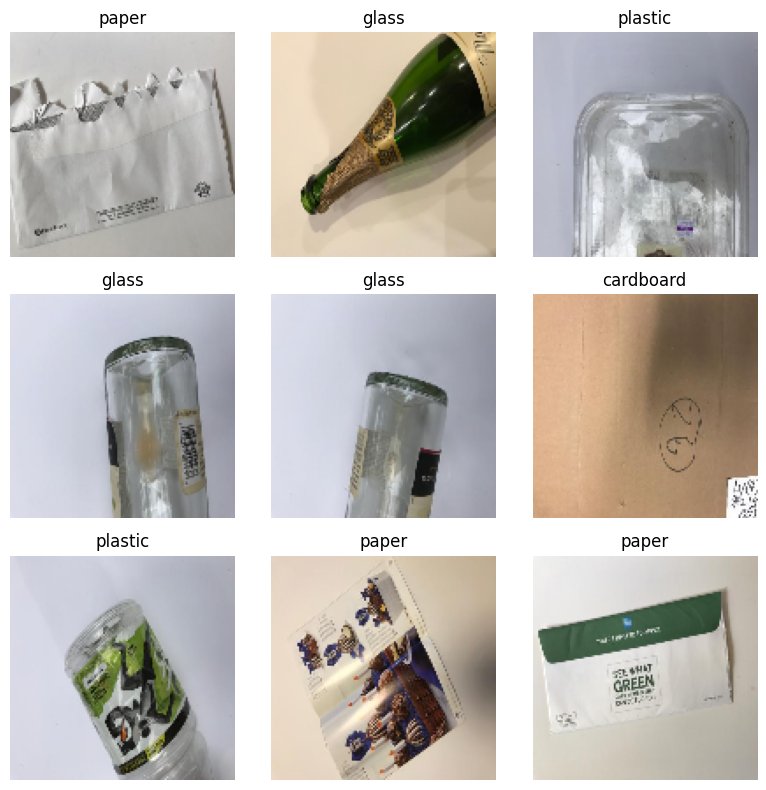

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Check class mapping
print("Class indices:", train_generator.class_indices)

# Show some sample images
images, labels = next(train_generator)
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    cls = list(train_generator.class_indices.keys())[np.argmax(labels[i])]
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history1 = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 942ms/step - accuracy: 0.9368 - loss: 0.1664 - val_accuracy: 0.5178 - val_loss: 2.2045
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 932ms/step - accuracy: 0.9484 - loss: 0.1445 - val_accuracy: 0.5415 - val_loss: 2.1485
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 929ms/step - accuracy: 0.9461 - loss: 0.1549 - val_accuracy: 0.5296 - val_loss: 2.1937
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 929ms/step - accuracy: 0.9523 - loss: 0.1326 - val_accuracy: 0.5494 - val_loss: 2.3892
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 933ms/step - accuracy: 0.9455 - loss: 0.1500 - val_accuracy: 0.5000 - val_loss: 2.4872
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 946ms/step - accuracy: 0.9464 - loss: 0.1400 - val_accuracy: 0.5040 - val_loss: 2.2990
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9656 - loss: 0.1076 - val_accuracy: 0.5455 - val_loss: 2.7336
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 929ms/step - accuracy: 0.9599 - loss: 0.1099 - val_accurac

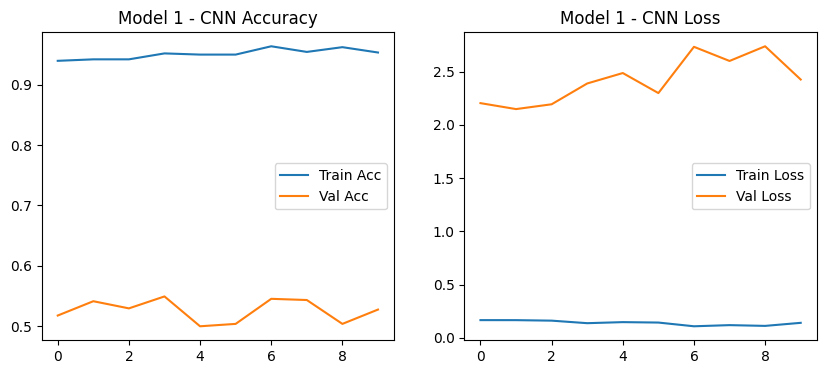

In [ ]:
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.title('Model 1 - CNN Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Model 1 - CNN Loss')
plt.legend()

plt.show()


In [ ]:
import os

# Create results directory if not exists
os.makedirs("/content/drive/MyDrive/Waste_Classification_Project/results", exist_ok=True)

# Save trained model
model1.save("/content/drive/MyDrive/Waste_Classification_Project/results/model1_cnn.h5")

# Save training plots
plt.savefig("/content/drive/MyDrive/Waste_Classification_Project/results/model1_cnn_training_curves.png")


<Figure size 640x480 with 0 Axes>

In [18]:
loss, acc = model1.evaluate(val_generator)
print(f"Validation Accuracy: {acc*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step - accuracy: 0.5078 - loss: 2.4999
Validation Accuracy: 52.77%
Validation Loss: 2.4263


In [35]:
from google.colab import files
files.download('/content/drive/MyDrive/Waste_Classification_Project/results/model1_cnn.h5')
files.download('/content/drive/MyDrive/Waste_Classification_Project/results/model1_cnn_training_curves.png')
files.download('/content/drive/MyDrive/Waste_Classification_Project/notebooks/01_Data_Preprocessing.ipynb')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/drive/MyDrive/Waste_Classification_Project/notebooks/01_Data_Preprocessing.ipynb